In [51]:
import os 
import sys
import sqlite3
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

# --- PATH SETUP --- 
current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, os.pardir))
data_dir = os.path.join(project_root, "data")
database_path = os.path.join(data_dir, 'training_analytics_DB.db')

# --- FUNCTIONS --- 
def get_volume_data():
    query = "SELECT * FROM v_category_volume"
    return pd.read_sql_query(query, conn)

def get_intensity_data():
    query = "SELECT * FROM v_lift_intensity"
    return pd.read_sql_query(query, conn)

def get_acwr_data():
    query = "SELECT * FROM v_weekly_workload_by_group"
    return pd.read_sql_query(query, conn)

In [52]:
# Establish connection with SQLite Database
conn = sqlite3.connect(database_path)

# Obtain datasets 
df_intensity = get_intensity_data()
df_acwr =get_acwr_data()

conn.close()

In [317]:
for container in ax1.containers:
    if container.get_label() == 'Total':
        

[<BarContainer object of 4 artists>,
 <BarContainer object of 4 artists>,
 <BarContainer object of 4 artists>]

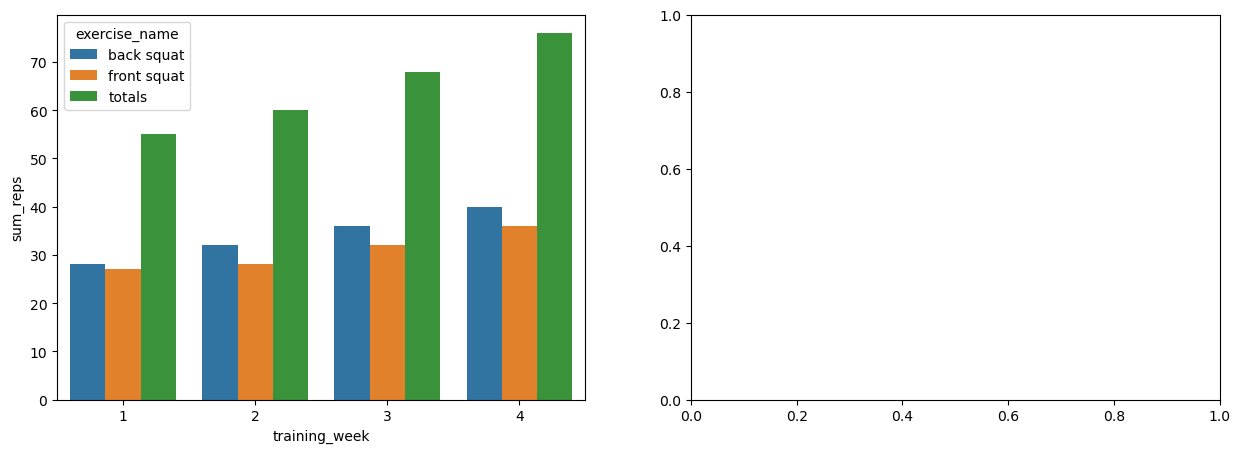

In [324]:
# Calculate the weekly total reps and format it to match the main dataframe structure
df_totals = df_intensity.groupby('training_week')['sum_reps'].sum().reset_index()
df_totals[['exercise_name', 'lift_group']] = ['totals', 'squat']

# Combine the original dataframe with the new total rows
df_plot = pd.concat([df_intensity, df_totals], ignore_index=True)

y_min = df_plot['sum_reps'].min()
y_max = df_plot['sum_reps'].max()

# Create a figure layout with two stacked subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- Top Window: Volume Plot ---
sns.barplot(
    data=df_plot, 
    x='training_week', 
    y='sum_reps', 
    hue='exercise_name', 
    ax=ax1
)

for container in ax1.containers:
    if container == '_container2':
        ax1.bar_label(container, fmt='%d', padding=0, weight='bold')

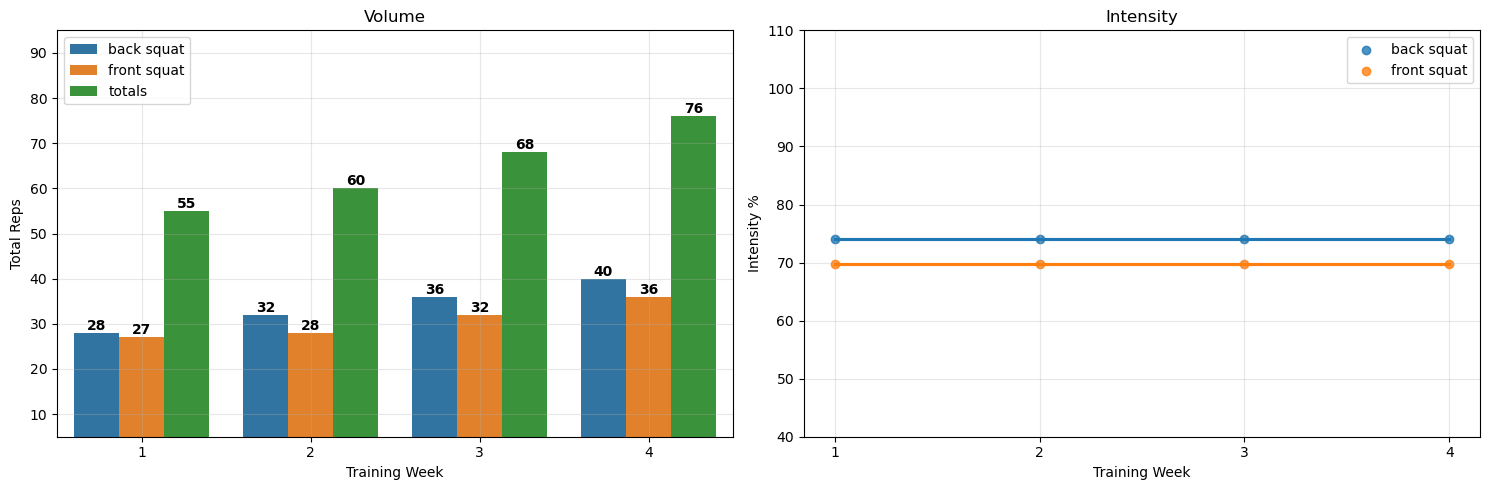

In [316]:
# Calculate the weekly total reps and format it to match the main dataframe structure
df_totals = df_intensity.groupby('training_week')['sum_reps'].sum().reset_index()
df_totals[['exercise_name', 'lift_group']] = ['totals', 'squat']

# Combine the original dataframe with the new total rows
df_plot = pd.concat([df_intensity, df_totals], ignore_index=True)

y_min = df_plot['sum_reps'].min()
y_max = df_plot['sum_reps'].max()

# Create a figure layout with two stacked subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# --- Top Window: Volume Plot ---
sns.barplot(
    data=df_plot, 
    x='training_week', 
    y='sum_reps', 
    hue='exercise_name', 
    ax=ax1
)

for container in ax1.containers:
    ax1.bar_label(container, fmt='%d', padding=0, weight='bold')
    
ax1.set_ylim(round_to_nearest_5(y_min*0.25), round_to_nearest_5(y_max*1.25))
ax1.set_xlabel("Training Week")
ax1.set_ylabel("Total Reps")
ax1.grid(True, alpha=0.3)
ax1.legend(title='')
ax1.set_title('Volume')

# --- Bottom Window: Intensity Trend with Best Fit Lines ---
for exercise in df_intensity['exercise_name'].unique():
    df_sub = df_intensity[df_intensity['exercise_name'] == exercise]
    sns.regplot(
        data=df_sub, 
        x='training_week', 
        y='intensity_pct', 
        ax=ax2, 
        ci=None, 
        scatter=True, 
        label=exercise
    )
ax2.set_ylim(40, 110)
ax2.get_xticks()
ax2.set_xticks(df_intensity['training_week'].unique())
ax2.set_xlabel("Training Week")
ax2.set_ylabel("Intensity %")
ax2.grid(True, alpha=0.3)
ax2.legend(title='')
ax2.set_title('Intensity')

fig.tight_layout()

In [184]:
x_indices = range(0, df_acwr['training_week'].max())
list(x_indices)

[0, 1, 2, 3]

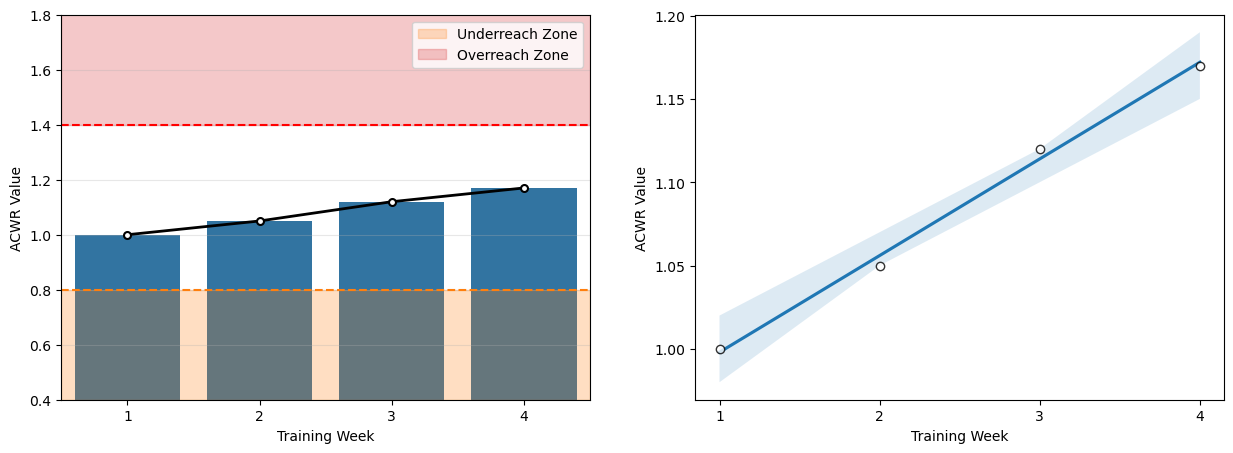

In [314]:
# VISUALIZATION 1: ACWR TREND ---
fig_acwr, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(df_acwr, x='training_week', y='ACWR', ax=ax1)
sns.pointplot(df_acwr, x='training_week', y='ACWR', color='black', linewidth=2, markerfacecolor='white', markeredgecolor='black', ax=ax1)
ax1.axhline(y=1.4, color='red', linestyle='--')
ax1.axhline(y=0.8, color='tab:orange', linestyle='--')
ax1.axhspan(0.4, 0.8, color='tab:orange', alpha=0.25, label='Underreach Zone')
ax1.axhspan(1.4, 2.0, color='tab:red', alpha=0.25, label='Overreach Zone')

ax1.set_ylabel('ACWR Value')
ax1.set_xlabel('Training Week')
ax1.set_ylim(0.4, 1.8)
ax1.grid(axis='y', alpha=0.3)
ax1.legend(loc=1);

sns.regplot(data=df_acwr, x='training_week', y='ACWR', ax=ax2, scatter_kws={'edgecolor': 'black', 'facecolor': 'white', 'zorder': 3}, line_kws={'zorder': 2})
ax2.set_xticks(df_intensity['training_week'].unique())
ax2.set_ylabel('ACWR Value')
ax2.set_xlabel('Training Week');

In [ ]:
# VISUALIZATION 2: ACWR TREND ---
fig_acwr, ax_acwr = plt.subplots(figsize=(10, 4))

weeks = df_acwr['training_week'].astype(str)
ratios = df_acwr['ACWR']

ax_acwr.bar(weeks, ratios, color='lightgray', edgecolor='black', alpha=0.7)
ax_acwr.axhline(y=1.3, color='red', linestyle='--')
ax_acwr.axhline(y=0.8, color='red', linestyle='--')

ax_acwr.set_ylabel('ACWR Value')
ax_acwr.set_ylim(0, max(ratios.max() + 0.2, 1.6));
#ax_acwr.legend(loc='upper left')